In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import h5py

mpl.rcParams['font.family'] = 'Nimbus Roman'
plt.rcParams['font.size'] = 15

In [2]:
def compute_bin_edges(pt_min, pt_max, n_pt, eta_min, eta_max, n_eta, phi_min, phi_max, n_phi):
    pt_bins = np.linspace(pt_min, pt_max, n_pt) #(pt_min, ..., pt_max)
    eta_bins = np.linspace(eta_min, eta_max, n_eta) #(eta_min, ..., eta_max)
    phi_bins = np.linspace(phi_min, phi_max, n_phi) #(phi_min, ..., phi_max)
    
    return pt_bins, eta_bins, phi_bins

In [3]:
pt_min = -0.7633162140846252 
pt_max = 6.748834133148193
n_pt = 40
eta_min = -0.8 
eta_max = 0.8
n_eta = 30
phi_min = -0.8 
phi_max = 0.8
n_phi = 30

pt_edges, eta_edges, phi_edges = compute_bin_edges(pt_min, pt_max, n_pt, eta_min, eta_max, n_eta, phi_min, phi_max, n_phi)


In [8]:
#qcd test data
QCD_data = pd.read_hdf("/hpcwork/rwth0934/hep_foundation_model/preprocessed_data/QCD_test_processed.h5",key = "discretized", stop = 50000).head(int(200*10**3)).to_numpy()    #600k

QCD_FACTORIZED_sampled_jets = np.array(h5py.File("/hpcwork/rwth0934/hep_foundation_model/sampled_jets/QCD_600000_FACTORIZED_sampled_50000_topk.h5").get("sampled_jets"))
QCD_LINEAR_sampled_jets  = np.array(h5py.File("/hpcwork/rwth0934/hep_foundation_model/sampled_jets/QCD_600000_LINEAR_sampled_50000_topk.h5").get("sampled_jets"))

print(QCD_data.shape)
print(QCD_FACTORIZED_sampled_jets.shape)
print(QCD_LINEAR_sampled_jets.shape)


(50000, 600)
(50000, 600)
(50000, 600)


In [9]:
#qcd test data
TTBar_data = pd.read_hdf("/hpcwork/rwth0934/hep_foundation_model/preprocessed_data/TTBar_test_processed.h5",key = "discretized", stop = 50000).head(int(200*10**3)).to_numpy()    #600k

TTBar_FACTORIZED_sampled_jets = np.array(h5py.File("/hpcwork/rwth0934/hep_foundation_model/sampled_jets/TTBar_600000_FACTORIZED_sampled_50000_topk.h5").get("sampled_jets"))
TTBar_LINEAR_sampled_jets  = np.array(h5py.File("/hpcwork/rwth0934/hep_foundation_model/sampled_jets/TTBar_600000_LINEAR_sampled_50000_topk.h5").get("sampled_jets"))

print(TTBar_data.shape)
print(TTBar_FACTORIZED_sampled_jets.shape)
print(TTBar_LINEAR_sampled_jets.shape)


(50000, 600)
(50000, 600)
(50000, 600)


In [10]:
def bins_to_continuous(bin_array, edges):
    result = np.full(bin_array.shape, np.nan)

    # gültige In-Range-Bins (1..n_bins)
    valid = (bin_array > 0) & (bin_array < len(edges))
    k = bin_array[valid]

    result[valid] = 0.5 * (edges[k-1] + edges[k])

    return result

def make_continuous(data, logpt_bins, eta_phi_bins):

    jets = data[:, :300]

    logpt_disc = jets[:, 0::3]
    eta_disc = jets[:, 1::3]
    phi_disc = jets[:, 2::3]

    mask = (logpt_disc == -1)
    N_constituents = np.sum(~mask, axis=1)

    logpt_con = bins_to_continuous(logpt_disc, logpt_bins)
    Delta_eta_con = bins_to_continuous(eta_disc, eta_phi_bins)
    Delta_phi_con = bins_to_continuous(phi_disc, eta_phi_bins)

    return N_constituents, logpt_con, Delta_eta_con, Delta_phi_con

def calc_m(logpt_con, Delta_eta_con, Delta_phi_con):

    eta_abs = Delta_eta_con 
    phi_abs = Delta_phi_con

    # Optional: bring phi in -pi..pi Bereich, falls nötig
    phi_abs = (phi_abs + np.pi) % (2*np.pi) - np.pi

    # pT: exponentiere logpt
    pt_con = np.exp(logpt_con)
    pt_con[np.isnan(pt_con)] = 0.0

    # Für physikalische Summen Constituents mit NaN pT auf 0 setzen:
    pt_con_nonan = np.where(np.isnan(pt_con), 0.0, pt_con)
    # Für angles: Constituents ohne pT können beliebige eta/phi haben; sie tragen nichts bei wenn pt==0.
    eta_for_p = np.where(np.isnan(eta_abs), 0.0, eta_abs)
    phi_for_p = np.where(np.isnan(phi_abs), 0.0, phi_abs)

    pxs = np.cos(phi_for_p) * pt_con_nonan
    pys = np.sin(phi_for_p) * pt_con_nonan
    pzs = np.sinh(eta_for_p) * pt_con_nonan
    Es = np.sqrt(pxs**2 + pys**2 + pzs**2)

    px_j = np.sum(pxs, axis=-1)
    py_j = np.sum(pys, axis=-1)
    pz_j = np.sum(pzs, axis=-1)
    E_j = np.sum(Es, axis=-1)

    m2 = E_j**2 - (px_j**2 + py_j**2 + pz_j**2)
    # numerische Rundungsfehler verhindern negative inside sqrt
    m2 = np.where(m2 < 0, 0.0, m2)
    m_j = np.sqrt(m2)

    return m_j

In [11]:
QCD_data_N_constituents, QCD_data_logpT_con, QCD_data_Delta_eta_con, QCD_data_Delta_phi_con = make_continuous(QCD_data, pt_edges, phi_edges)
QCD_data_mj = calc_m(QCD_data_logpT_con, QCD_data_Delta_eta_con, QCD_data_Delta_phi_con)

QCD_sampled_600k_Model_N_constituents, QCD_sampled_600k_Model_logpT_con, QCD_sampled_600k_Model_Delta_eta_con, QCD_sampled_600k_Model_Delta_phi_con = make_continuous(QCD_FACTORIZED_sampled_jets, pt_edges, phi_edges)
QCD_sampled_600k_Model_mj = calc_m(QCD_sampled_600k_Model_logpT_con, QCD_sampled_600k_Model_Delta_eta_con, QCD_sampled_600k_Model_Delta_phi_con)


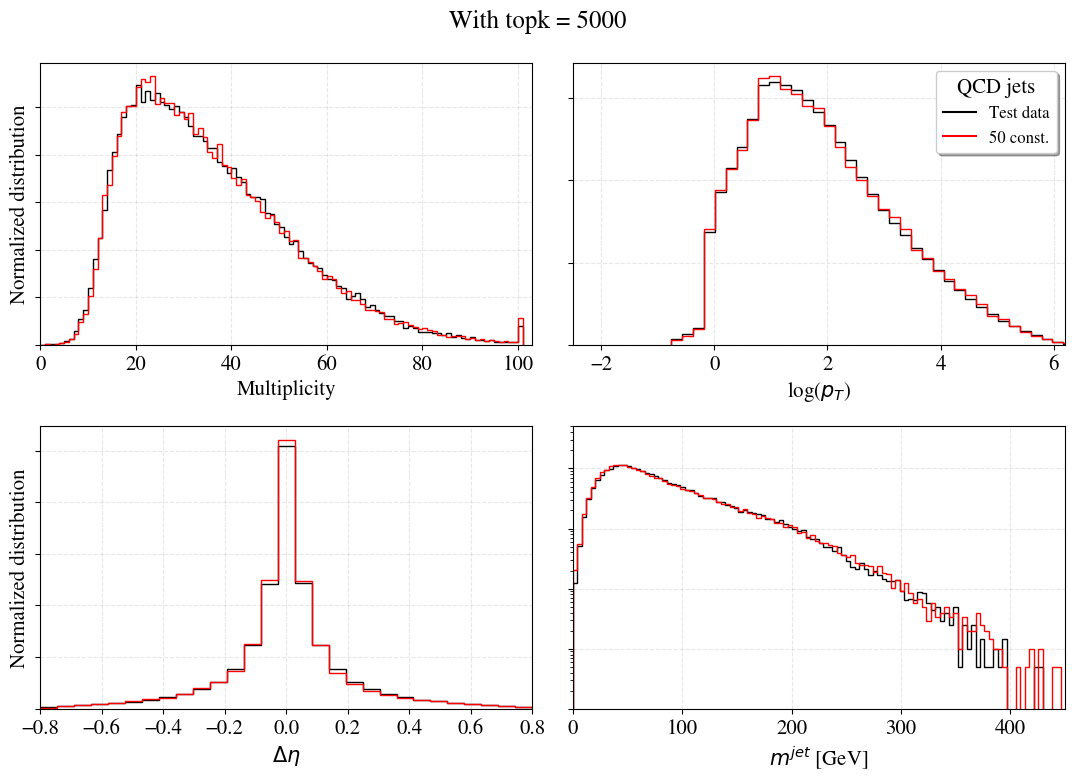

In [ ]:
fig1, ax1 = plt.subplots(2,2, figsize=(11,8), dpi=100)

ax1[0,0].hist(QCD_data_N_constituents, bins = 101, histtype="step", range=(0,101), color="black", density=True)
ax1[0,0].hist(QCD_sampled_600k_Model_N_constituents, bins = 101, histtype="step", range=(0,101), color="red", density=True)

ax1[0,1].hist(QCD_data_logpT_con.flatten(), bins = 39, histtype="step", range=(min(pt_edges),max(pt_edges)), color="black", density=True)
ax1[0,1].hist(QCD_sampled_600k_Model_logpT_con.flatten(), bins = 39, histtype="step", range=(min(pt_edges),max(pt_edges)), color="red", density=True)

ax1[1,0].hist(QCD_data_Delta_eta_con.flatten(), bins = 29, histtype="step", range=(-0.8,0.8), color="black", density=True)
ax1[1,0].hist(QCD_sampled_600k_Model_Delta_eta_con.flatten(), bins = 29, histtype="step", range=(-0.8,0.8), color="red", density=True)

ax1[1,1].hist(QCD_data_mj, bins = 110, histtype="step", range=(0,450), color="black", density=True)
ax1[1,1].hist(QCD_sampled_600k_Model_mj, bins = 110, histtype="step", range=(0,450), color="red", density=True)


ax1[0,0].set_xlabel("Multiplicity")
ax1[0,1].set_xlabel(r"log($p_T$)")
ax1[1,0].set_xlabel(r"$\Delta \eta$")
ax1[1,1].set_xlabel(r"$m^{jet}$ [GeV]")

ax1[0,0].set_ylabel("Normalized distribution")
ax1[1,0].set_ylabel("Normalized distribution")

ax1[1,1].set_yscale("log")

for i in range(2):
    for j in range(2):
        ax1[i,j].tick_params(labelleft=False)
        ax1[i,j].grid(linestyle="--", alpha=0.3)
        ax1[i,j].set_axisbelow(True)

ax1[0,0].set_xlim(0,103)
#ax1[0,0].set_xlim(0,55)
#ax1[0,0].set_ylim(0,0.05)
ax1[0,1].set_xlim(-2.5,6.2)
ax1[1,0].set_xlim(-0.8,0.8)
ax1[1,1].set_xlim(0,450)

ax1[1,1].set_ylim(10**(-6),5*10**(-2))

ax1[0,1].plot(-5,0, color="black", label="Test data")
ax1[0,1].plot(-5,0, color="red", label="Sampled data factorized")

ax1[1,0].set_xticks(np.linspace(-0.8,0.8,9))

ax1[0,1].legend(loc="upper right", title="QCD jets", shadow=True, fontsize=12)

fig1.suptitle("With topk = 5000")
plt.tight_layout()
plt.show()